# Chapter 7 - Support Vector Machines and Kernel Methods

Reproduksi pembelajaran **scikit-learn Cookbook, Third Edition**, John Sukup (Packt, 2025), untuk mata kuliah Pembelajaran Mesin.

Kode diadaptasi dari [repo penerbit](https://github.com/PacktPublishing/scikit-learn-Cookbook-Third-Edition/tree/c624b1279cf23a83273e806cede15cad0c9e5500/Chapter_7) beserta exercise solutions. Teori dan interpretasi disusun dalam bahasa Indonesia. Perubahan penting dijelaskan di README. Dataset sintetis diberi label, output disimpan, dan seluruh notebook dapat dijalankan ulang dari kernel baru.

## Daftar Isi

- [Introduction to SVMs](#introduction-to-svms)
- [Kernel Functions and Their Applications](#kernel-functions-and-their-applications)
- [Tuning SVM Parameters](#tuning-svm-parameters)
- [SVMs in High-Dimensional Spaces](#svms-in-high-dimensional-spaces)
- [Evaluating SVM Models](#evaluating-svm-models)
- [Practical Exercises with SVMs](#practical-exercises-with-svms)
- [Tambahan: SVR dengan Target Kontinu](#tambahan-svr-dengan-target-kontinu)
- [Pemeriksaan Hasil](#pemeriksaan-hasil)
- [Ringkasan Bab](#ringkasan-bab)

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score
from sklearn.utils import Bunch

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
DATA_DIR = ROOT / 'data'
np.random.seed(2024)
pd.set_option('display.max_columns', 12)
pd.set_option('display.max_rows', 25)
plt.rcParams.update({'figure.dpi': 100, 'savefig.bbox': 'tight'})

## Introduction to SVMs

Support Vector Classification mencari hyperplane dengan margin lebar. Pada soft margin, objektif menggabungkan $\|w\|^2/2$ dengan penalti C terhadap slack/error margin. C besar memberi penalti lebih kuat pada pelanggaran margin; C kecil mengizinkan margin lebih lunak. Support vectors adalah pengamatan yang menentukan solusi, bukan semua training point.

SVR memakai loss epsilon-insensitive: error di dalam tabung epsilon tidak diberi penalti, sedangkan error di luar diperhitungkan. Contoh sumber meregresikan nomor kelas Iris sebagai respons kontinu. Reproduksi mempertahankan contoh itu dengan batasan eksplisit: nomor kelas tidak mempunyai skala kuantitatif alami, sehingga MSE tersebut tidak menilai klasifikasi. Ilustrasi tambahan memakai target regresi kontinu yang sesuai.

In [2]:
# Load libraries 
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC, SVR
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

# Load the dataset
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2024)

In [3]:
# Load the model
svm_classifier = make_pipeline(StandardScaler(), SVC(kernel='linear'))

# Train the model
svm_classifier.fit(X_train, y_train)

# Make predictions
y_pred = svm_classifier.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()

# Stylize the DataFrame
styled_df = (report_df
    .style
    .background_gradient(cmap='Blues', subset=['precision', 'recall', 'f1-score'])
    .format({
        'precision': '{:.3f}',
        'recall': '{:.3f}', 
        'f1-score': '{:.3f}',
        'support': '{:.0f}'
    })
)

print(f"Accuracy: {accuracy:.2f}")
styled_df

iris_linear_accuracy = accuracy

Accuracy: 0.93


In [4]:
# Load the model
svm_regressor = SVR(kernel='rbf')

# Train the model
svm_regressor.fit(X_train[:, :2], y_train)

# Make predictions
y_pred_reg = svm_regressor.predict(X_test[:, :2])

# Evaluate the model
# Note: For regression, we typically use metrics like MSE or R-squared
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test, y_pred_reg)
print(f"MSE: {mse:.2f}")

MSE: 0.20


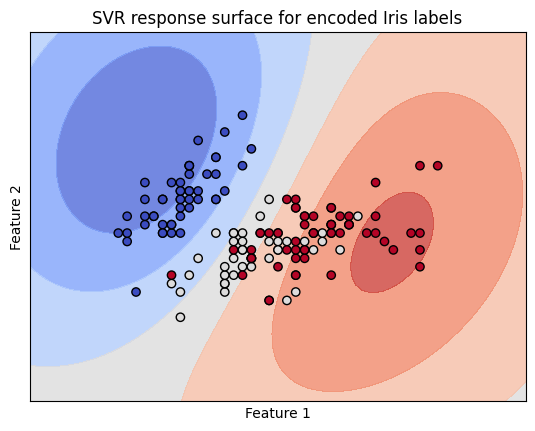

In [5]:
# Load the libraries
import matplotlib.pyplot as plt
import numpy as np
from sklearn.inspection import DecisionBoundaryDisplay

# Create a mesh grid
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01))

# Adjust the input to match the expected number of features
# Use all four features for prediction, but only visualize the first two
grid_points = np.c_[xx.ravel(), yy.ravel(), np.zeros((xx.ravel().shape[0], 2))]

# Plot decision boundaries using DecisionBoundaryDisplay
fig, ax = plt.subplots()
disp = DecisionBoundaryDisplay.from_estimator(
    svm_regressor,
    grid_points[:, :2],
    response_method="predict",
    plot_method="contourf",
    cmap=plt.cm.coolwarm,
    alpha=0.8,
    ax=ax
)

# Plot the data points
ax.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', marker='o', cmap=plt.cm.coolwarm)
ax.set_title("SVR response surface for encoded Iris labels")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_xlim(xx.min(), xx.max())
ax.set_ylim(yy.min(), yy.max())
ax.set_xticks(())
ax.set_yticks(())
plt.show()

## Kernel Functions and Their Applications

Kernel trick menghitung inner product pada ruang fitur implisit tanpa membangun seluruh fitur. Kernel linear memakai $x^Tz$, polynomial memakai $(\gamma x^Tz+r)^d$, dan RBF memakai $e^{-\gamma\|x-z\|^2}$. Gamma besar membuat pengaruh titik lebih lokal dan dapat meningkatkan variance; kecil membuat batas lebih halus. Sigmoid memiliki perilaku berbeda dan tidak cocok otomatis untuk setiap data.

Perbandingan kernel Iris memakai fitur dan split sama. Plot 2D melatih model baru hanya pada dua fitur; hasilnya berbeda dari model empat fitur. Area kontur adalah label prediksi, bukan probabilitas atau bukti kualitas di seluruh ruang.

In [6]:
# Load the libraries
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2024)

In [7]:
# Load the model
svm_poly = make_pipeline(StandardScaler(), SVC(kernel='poly', degree=3))

# Train the model
svm_poly.fit(X_train, y_train)

# Make predictions
y_pred_poly = svm_poly.predict(X_test)

# Evaluate the model
accuracy_poly = accuracy_score(y_test, y_pred_poly)
report_poly = classification_report(y_test, y_pred_poly, output_dict=True)
report_df_poly = pd.DataFrame(report_poly).transpose()

# Stylize the DataFrame
styled_df_poly = (report_df_poly
    .style
    .background_gradient(cmap='Blues', subset=['precision', 'recall', 'f1-score'])
    .format({
        'precision': '{:.3f}',
        'recall': '{:.3f}', 
        'f1-score': '{:.3f}',
        'support': '{:.0f}'
    })
)

print(f"Polynomial Kernel Accuracy: {accuracy_poly:.2f}")
styled_df_poly

Polynomial Kernel Accuracy: 0.84


,precision,recall,f1-score,support
0,1.000,1.000,1.000,18
1,0.647,0.917,0.759,12
2,0.900,0.600,0.720,15
accuracy,0.844,0.844,0.844,1
macro avg,0.849,0.839,0.826,45
weighted avg,0.873,0.844,0.842,45


In [8]:
# Load the model
svm_rbf = make_pipeline(StandardScaler(), SVC(kernel='rbf'))

# Train the model
svm_rbf.fit(X_train, y_train)

# Make predictions
y_pred_rbf = svm_rbf.predict(X_test)

# Evaluate the model
accuracy_rbf = accuracy_score(y_test, y_pred_rbf)
report_rbf = classification_report(y_test, y_pred_rbf, output_dict=True)
report_df_rbf = pd.DataFrame(report_rbf).transpose()

# Stylize the DataFrame
styled_df_rbf = (report_df_rbf
    .style
    .background_gradient(cmap='Blues', subset=['precision', 'recall', 'f1-score'])
    .format({
        'precision': '{:.3f}',
        'recall': '{:.3f}', 
        'f1-score': '{:.3f}',
        'support': '{:.0f}'
    })
)

print(f"RBF Kernel Accuracy: {accuracy_rbf:.2f}")
styled_df_rbf

RBF Kernel Accuracy: 0.93


,precision,recall,f1-score,support
0,1.000,1.000,1.000,18
1,0.909,0.833,0.870,12
2,0.875,0.933,0.903,15
accuracy,0.933,0.933,0.933,1
macro avg,0.928,0.922,0.924,45
weighted avg,0.934,0.933,0.933,45


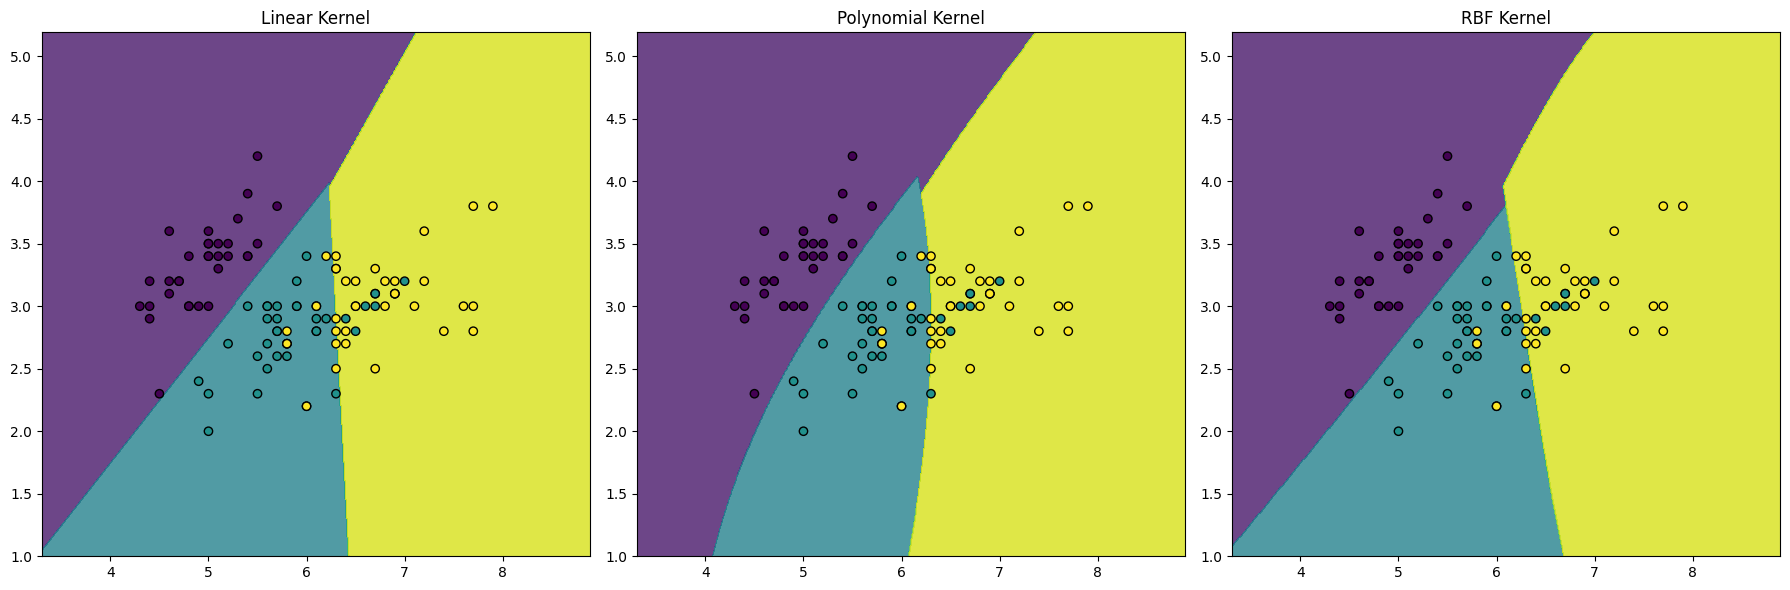

In [9]:
# Create a mesh grid using only the first two features for visualization
x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01))

# Use only the first two features for prediction
X_train_2d = X_train[:, :2]

# Train new SVM models using only the first two features
svm_linear_2d = SVC(kernel='linear').fit(X_train_2d, y_train)
svm_poly_2d = SVC(kernel='poly').fit(X_train_2d, y_train)
svm_rbf_2d = SVC(kernel='rbf').fit(X_train_2d, y_train)

# Predict class probabilities across the grid for each kernel using only the first two features
Z_linear = svm_linear_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z_poly = svm_poly_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z_rbf = svm_rbf_2d.predict(np.c_[xx.ravel(), yy.ravel()])

Z_linear = Z_linear.reshape(xx.shape)
Z_poly = Z_poly.reshape(xx.shape)
Z_rbf = Z_rbf.reshape(xx.shape)

# Plot decision boundaries
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].contourf(xx, yy, Z_linear, alpha=0.8)
axes[0].scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train, edgecolors='k', marker='o')
axes[0].set_title("Linear Kernel")

axes[1].contourf(xx, yy, Z_poly, alpha=0.8)
axes[1].scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train, edgecolors='k', marker='o')
axes[1].set_title("Polynomial Kernel")

axes[2].contourf(xx, yy, Z_rbf, alpha=0.8)
axes[2].scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train, edgecolors='k', marker='o')
axes[2].set_title("RBF Kernel")

plt.tight_layout()
plt.show()

## Tuning SVM Parameters

Grid search memilih C, kernel, degree, dan gamma pada CV training. Parameter degree hanya relevan untuk kernel polynomial. Scaling berada di dalam pipeline sehingga statistik validation tidak dipakai saat fit scaler. Kurva skor terhadap C memperlihatkan trade-off pada grid, bukan bahwa C terbesar selalu terbaik.

In [10]:
# Load the libraries
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

# Load the dataset
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2024)

In [11]:
# Define the parameter grid
param_grid = {
    'svc__C': [0.1, 1, 10],
    'svc__kernel': ['linear', 'rbf', 'poly'],
    'svc__degree': [2, 3, 4]
}

# Perform grid search with cross-validation
grid_search = GridSearchCV(Pipeline([('scaler', StandardScaler()), ('svc', SVC(random_state=2024))]), param_grid, cv=5)
grid_search.fit(X_train, y_train)

# Get the best hyperparameters and score
best_params = grid_search.best_params_
best_score = grid_search.best_score_
print(f"Best Parameters: {best_params}")
print(f"Best Cross-Validation Score: {best_score:.2f}")

# Train a new model with the best hyperparameters
best_model = grid_search.best_estimator_
best_model.fit(X_train, y_train)

# Make predictions with the best model
y_pred = best_model.predict(X_test)

# Evaluate the best model
accuracy = accuracy_score(y_test, y_pred)
report_df = pd.DataFrame(classification_report(y_test, y_pred, output_dict=True)).transpose()

# Stylize the DataFrame
styled_report_df = (report_df
    .style
    .background_gradient(cmap='Blues', subset=['precision', 'recall', 'f1-score'])
    .format({
        'precision': '{:.3f}',
        'recall': '{:.3f}', 
        'f1-score': '{:.3f}',
        'support': '{:.0f}'
    })
)

print(f"Accuracy: {accuracy:.2f}")
styled_report_df

iris_svm_grid_cv = grid_search.best_score_

Best Parameters: {'svc__C': 1, 'svc__degree': 2, 'svc__kernel': 'linear'}
Best Cross-Validation Score: 0.99
Accuracy: 0.93


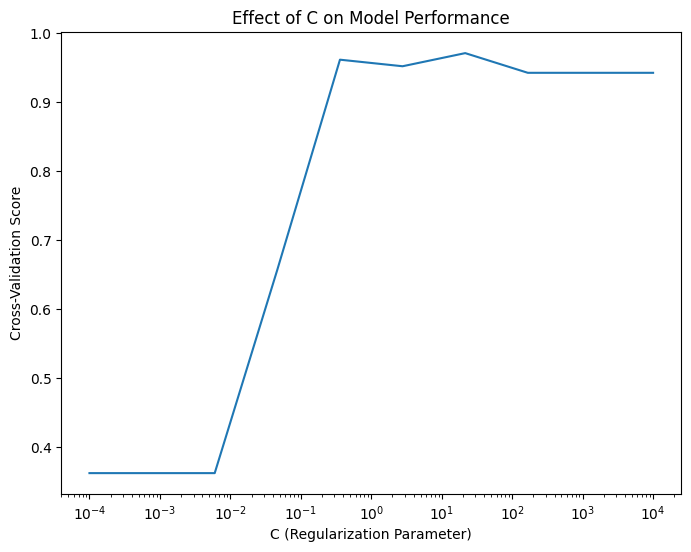

In [12]:
# Perform a grid search with a range of C values for a specific kernel
param_grid_c = {
    'svc__C': np.logspace(-4, 4, 10),
    'svc__kernel': ['rbf']
}
grid_search_c = GridSearchCV(Pipeline([('scaler', StandardScaler()), ('svc', SVC(random_state=2024))]), param_grid_c, cv=5)
grid_search_c.fit(X_train, y_train)

# Plot the cross-validation scores against C values
plt.figure(figsize=(8, 6))
plt.plot(grid_search_c.param_grid['svc__C'], grid_search_c.cv_results_['mean_test_score'])
plt.xscale('log')
plt.xlabel('C (Regularization Parameter)')
plt.ylabel('Cross-Validation Score')
plt.title('Effect of C on Model Performance')
plt.show()

## SVMs in High-Dimensional Spaces

SVM linear dapat bekerja saat jumlah fitur besar, tetapi noise, kompleksitas margin, dan jumlah sampel tetap memengaruhi generalisasi. Contoh sintetis memiliki 1.000 sampel, 1.000 fitur, serta 50 fitur informatif. LinearSVC menggunakan implementasi linear yang dapat lebih efisien untuk skala besar dibanding SVC kernel linear, dengan fungsi loss dan parameter yang perlu diperhatikan.

PCA 2D pada seluruh dataset hanya untuk visualisasi dan tidak digunakan dalam pemodelan test. Plot yang tampak tumpang tindih tidak membuktikan bahwa seluruh informasi kelas pada ruang 1.000 dimensi tidak berguna.

In [13]:
# Load the libraries
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd
import numpy as np

# Create a synthetic high-dimensional dataset
X, y = make_classification(n_samples=1000, n_features=1000, n_informative=50, n_redundant=0, random_state=2024)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2024)

In [14]:
# Load the model
svm_model = make_pipeline(StandardScaler(), SVC(kernel='linear'))

# Train the model
svm_model.fit(X_train, y_train)

# Make predictions
y_pred = svm_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report_df = pd.DataFrame(classification_report(y_test, y_pred, output_dict=True)).transpose()

# Stylize the DataFrame
styled_report_df = (report_df
    .style
    .background_gradient(cmap='Blues', subset=['precision', 'recall', 'f1-score'])
    .format({
        'precision': '{:.3f}',
        'recall': '{:.3f}', 
        'f1-score': '{:.3f}',
        'support': '{:.0f}'
    })
)

print(f"Accuracy: {accuracy:.2f}")
styled_report_df

Accuracy: 0.67


,precision,recall,f1-score,support
0,0.706,0.667,0.686,162
1,0.633,0.674,0.653,138
accuracy,0.670,0.670,0.670,1
macro avg,0.669,0.670,0.669,300
weighted avg,0.672,0.670,0.670,300


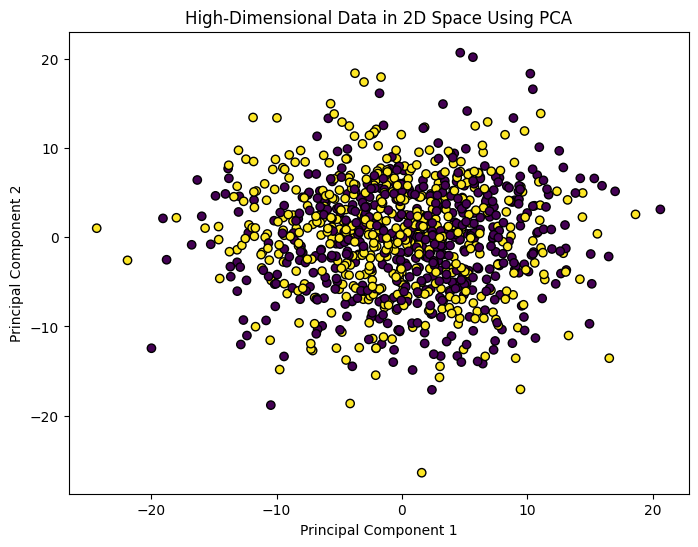

In [15]:
# Import PCA from sklearn.decomposition
from sklearn.decomposition import PCA

# Apply PCA to reduce dimensionality
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Plot the reduced data
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, edgecolors='k', marker='o')
plt.title("High-Dimensional Data in 2D Space Using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

## Evaluating SVM Models

Confusion matrix dan precision/recall/F1 menunjukkan jenis kesalahan. SVC dapat menghasilkan probability setelah kalibrasi internal bila `probability=True`, tetapi membutuhkan komputasi tambahan. ROC dapat juga memakai decision_function; AUC menilai ranking, bukan kalibrasi. Pada Breast Cancer, label positif default adalah benign, bukan malignant. Scaling dan tuning dipelajari dari training dan test hanya memberi evaluasi pada split tersebut.

In [16]:
# Load the libraries
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import classification_report, roc_curve, auc
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2024)

In [17]:
# Load the model
svm_model = make_pipeline(StandardScaler(), SVC(kernel='linear', probability=True, random_state=2024))

# Train the model
svm_model.fit(X_train, y_train)

# Make predictions
y_pred = svm_model.predict(X_test)
y_prob = svm_model.predict_proba(X_test)[:, 1]

# Evaluate the model
report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()

# Stylize the DataFrame
styled_report_df = (report_df
    .style
    .background_gradient(cmap='Blues', subset=['precision', 'recall', 'f1-score'])
    .format({
        'precision': '{:.3f}',
        'recall': '{:.3f}', 
        'f1-score': '{:.3f}',
        'support': '{:.0f}'
    })
)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
styled_report_df

svm_cancer_pipeline = svm_model

Accuracy: 0.98


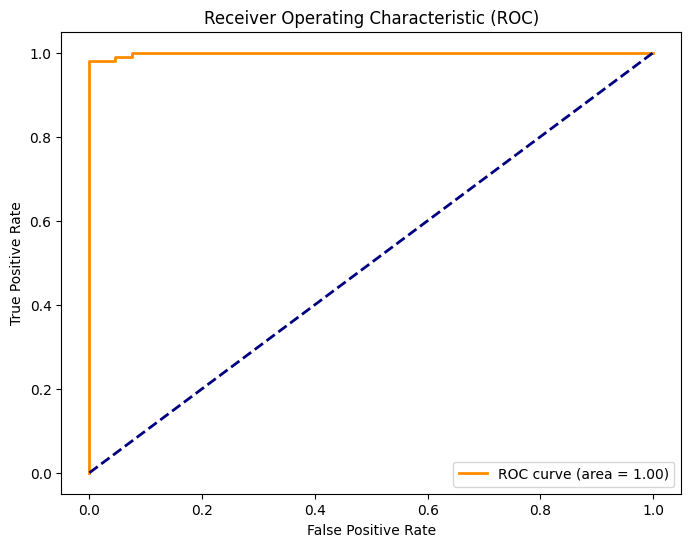

In [18]:
# Plot the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

svm_roc_auc = roc_auc

## Practical Exercises with SVMs

Latihan selesai mencakup SVM Iris, tuning SVM Breast Cancer, dan batas keputusan pada dataset sintetis dua fitur. Pipeline scaling menjaga konsistensi preprocessing per fold. Contoh regresi tambahan memakai fungsi kontinu dengan noise dan melaporkan RMSE, sehingga perbedaan tugas klasifikasi dan regresi dapat terlihat jelas.

### Latihan 1: Building a Simple SVM Classifier

SVM linear Iris memakai pipeline scaling dan menampilkan classification report. Holdout dipisahkan sebelum fit preprocessing.

In [19]:
# Load the libraries
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

# Load the dataset
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2024)

# Create and train a SVM classifier
svm_model = make_pipeline(StandardScaler(), SVC(kernel='linear'))
svm_model.fit(X_train, y_train)

# Make predictions
y_pred = svm_model.predict(X_test)

# Evaluate performance
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")
print("Classification Report:")
print(report)

Accuracy: 0.93
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       1.00      0.75      0.86        12
           2       0.83      1.00      0.91        15

    accuracy                           0.93        45
   macro avg       0.94      0.92      0.92        45
weighted avg       0.94      0.93      0.93        45



### Latihan 2: Tuning SVM Parameters with Grid Search

SVM Breast Cancer dituning dengan grid search pada C, kernel, dan degree. Scaler dipelajari pada tiap fold training melalui pipeline.

In [20]:
# Load the libraries
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

# Load the dataset
data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2024)

# Define a hyperparameter for grid search
param_grid = {
    'svc__C': [0.1, 1, 10],
    'svc__kernel': ['linear', 'rbf', 'poly'],
    'svc__degree': [2, 3, 4]
}

# Perform grid search with cross-validation
grid_search = GridSearchCV(Pipeline([('scaler', StandardScaler()), ('svc', SVC(random_state=2024))]), param_grid, cv=5)
grid_search.fit(X_train, y_train)


# Train a new model with the best hyperparameters
best_model = grid_search.best_estimator_
best_model.fit(X_train, y_train)

# Make predictions with the best model
y_pred_best = best_model.predict(X_test)

# Evaluate the best model
accuracy_best = accuracy_score(y_test, y_pred_best)
report_best = classification_report(y_test, y_pred_best)
print(f"Best Model Accuracy: {accuracy_best:.2f}")
print("Best Model Classification Report:")
print(report_best)

Best Model Accuracy: 0.98
Best Model Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.98        67
           1       0.98      0.99      0.99       104

    accuracy                           0.98       171
   macro avg       0.98      0.98      0.98       171
weighted avg       0.98      0.98      0.98       171



### Latihan 3: Visualizing SVM Decision Boundaries

SVM RBF dilatih pada dua fitur sintetis lalu dipetakan ke mesh grid. Kontur menampilkan label prediksi dan titik memberi konteks data yang tersedia.

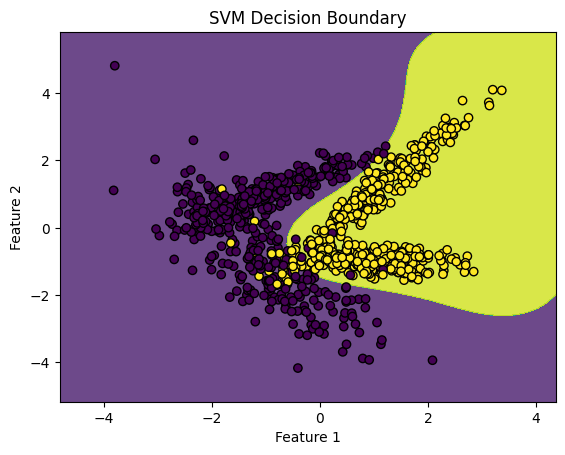

In [21]:
# Load libraries for visualization and dataset creation
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

# Create a synthetic dataset for binary classification
X, y = make_classification(n_samples=1000, n_features=2, n_classes=2, n_informative=2, n_redundant=0, random_state=2024)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2024)

# Create and train an SVM model
svm_model = make_pipeline(StandardScaler(), SVC(kernel='rbf'))
svm_model.fit(X_train, y_train)

# Create a mesh grid for plotting decision boundaries
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01))

# Predict class probabilities across the grid
Z = svm_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundaries
plt.contourf(xx, yy, Z, alpha=0.8)
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', marker='o')
plt.title("SVM Decision Boundary")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

## Tambahan: SVR dengan Target Kontinu

Target pada contoh ini adalah $\sin(x)$ ditambah noise Gaussian, sehingga RMSE mempunyai arti error respons kontinu. Pipeline scaling–SVR dilatih pada training dan dinilai pada test. Epsilon menyatakan lebar toleransi error dan C mengendalikan penalti pelanggarannya.

Continuous SVR test RMSE: 0.09270727787347799


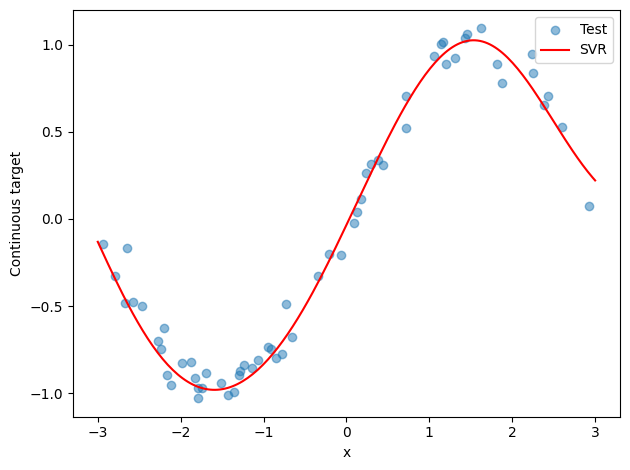

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
rng = np.random.default_rng(2024)
X_reg = rng.uniform(-3, 3, (300, 1))
y_reg = np.sin(X_reg[:, 0]) + rng.normal(0, 0.1, 300)
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=2024)
reg_pipeline = make_pipeline(StandardScaler(), SVR(C=10, epsilon=0.1))
reg_pipeline.fit(X_reg_train, y_reg_train)
continuous_svr_rmse = np.sqrt(mean_squared_error(y_reg_test, reg_pipeline.predict(X_reg_test)))
print('Continuous SVR test RMSE:', continuous_svr_rmse)
grid_reg = np.linspace(-3, 3, 200).reshape(-1, 1)
plt.scatter(X_reg_test[:,0], y_reg_test, label='Test', alpha=0.5)
plt.plot(grid_reg[:,0], reg_pipeline.predict(grid_reg), color='red', label='SVR')
plt.xlabel('x'); plt.ylabel('Continuous target'); plt.legend(); plt.tight_layout(); plt.show()

## Pemeriksaan Hasil

Angka berikut merangkum hasil eksekusi, disertai assertion untuk memeriksa konsistensi tertentu. Pemeriksaan kode tidak membuktikan asumsi statistik atau representativitas data.

In [23]:
chapter_results = {'iris_linear_accuracy': float(iris_linear_accuracy),
 'iris_poly_accuracy': float(accuracy_poly), 'iris_rbf_accuracy': float(accuracy_rbf),
 'iris_grid_cv_accuracy': float(iris_svm_grid_cv),
 'continuous_svr_test_rmse': float(continuous_svr_rmse),
 'benign_svm_roc_auc': float(svm_roc_auc)}
assert np.isfinite(continuous_svr_rmse) and continuous_svr_rmse >= 0
assert 'standardscaler' in svm_cancer_pipeline.named_steps
print(json.dumps(chapter_results, indent=2))

{
  "iris_linear_accuracy": 0.9333333333333333,
  "iris_poly_accuracy": 0.8444444444444444,
  "iris_rbf_accuracy": 0.9333333333333333,
  "iris_grid_cv_accuracy": 0.9904761904761905,
  "continuous_svr_test_rmse": 0.09270727787347799,
  "benign_svm_roc_auc": 0.9988518943742823
}


## Ringkasan Bab

Pada split Iris, accuracy SVM linear sekitar **93.33%**, polynomial **84.44%**, dan RBF **93.33%**. Grid search menghasilkan best CV score sekitar **99.05%**. Nilai ini bergantung pada fitur, scaling, split, serta ruang pencarian; nama kernel saja tidak menentukan performa.

C mengendalikan penalti pelanggaran margin dan gamma RBF mengendalikan jangkauan pengaruh titik. Plot dua fitur memakai model tersendiri dan tidak mewakili seluruh model empat fitur. Contoh SVR nomor kelas Iris dipertahankan sebagai ilustrasi API dengan batas interpretasi, sedangkan ilustrasi target kontinu menghasilkan **RMSE test 0.0927**. ROC-AUC SVM Breast Cancer sekitar **0.9989** memakai benign sebagai label positif. Evaluasi regresi, klasifikasi, dan probabilitas harus mengikuti arti target.